In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
mobile_sales = pd.read_csv('/content/drive/MyDrive/Time Series and Recsys data/time_series_2_data.csv')

In [ ]:
mobile_sales = mobile_sales.set_index('DATE')

In [ ]:
mobile_sales.index = pd.to_datetime(mobile_sales.index)

In [ ]:
mobile_sales = mobile_sales.asfreq('MS')

In [ ]:
train_x = mobile_sales.iloc[:193]
test_x = mobile_sales.iloc[193:]

In [ ]:
train_x

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2016-09-01,13713.00
2016-10-01,13342.00
2016-11-01,14455.00


<Axes: xlabel='DATE'>

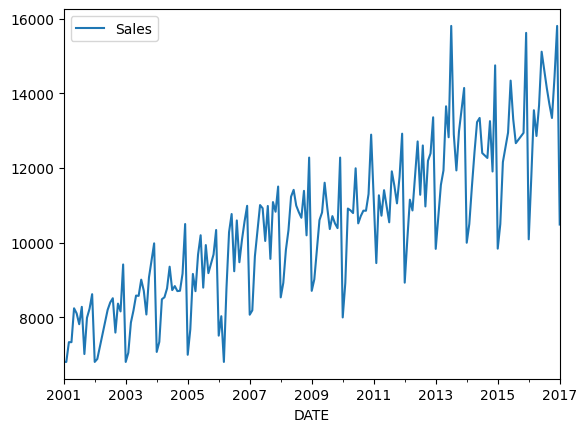

In [ ]:
train_x.plot()

<Axes: xlabel='DATE'>

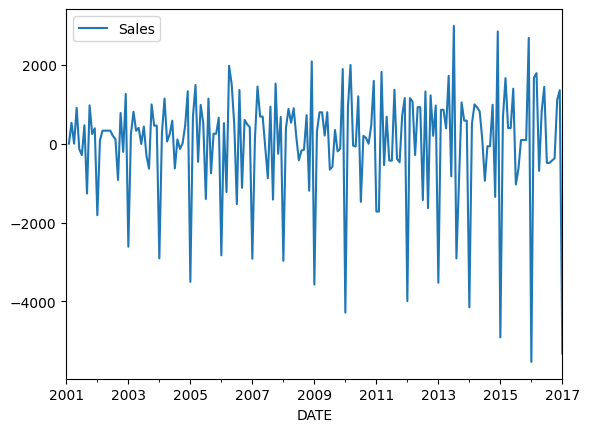

In [ ]:
train_x.diff(1).plot()

<Axes: xlabel='DATE'>

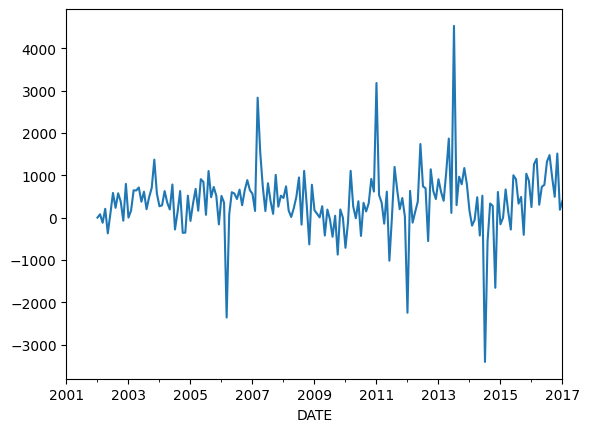

In [ ]:
train_x['Sales'].diff(12).plot()

In [ ]:
seasonal_diff = train_x['Sales'].diff(12).dropna()

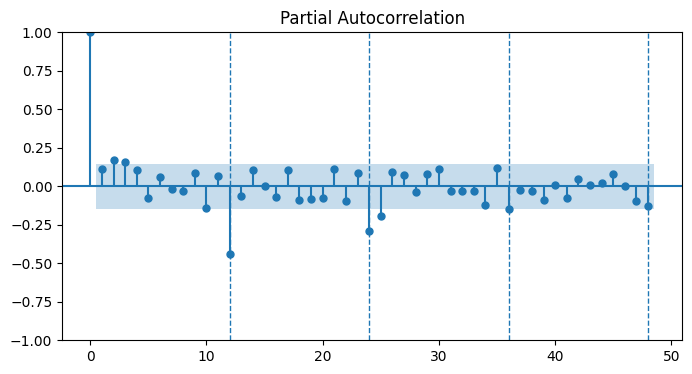

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

# Plot PACF
plot_pacf(seasonal_diff, lags=48, ax=ax)

# Mark seasonal lags
seasonal_lags = [12, 24, 36,48]

for lag in seasonal_lags:
    ax.axvline(lag, linestyle='--', linewidth=1)

plt.show()

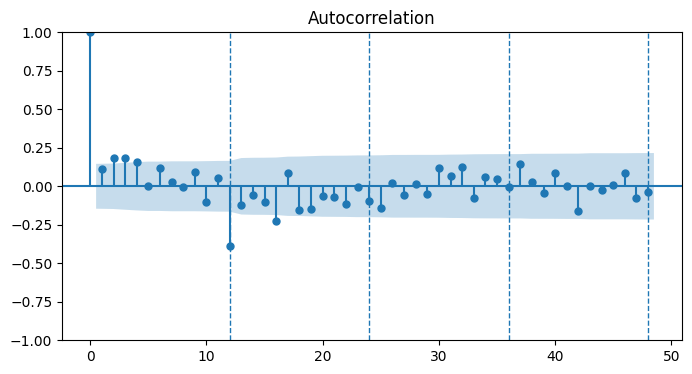

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

# Plot PACF
plot_acf(seasonal_diff, lags=48, ax=ax)

# Mark seasonal lags
seasonal_lags = [12, 24, 36,48]

for lag in seasonal_lags:
    ax.axvline(lag, linestyle='--', linewidth=1)

plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(train_x.Sales, order=(5, 1, 1),seasonal_order=(3,1,1,12))
model = model.fit(disp=False)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast_1 = model.forecast(steps=24)

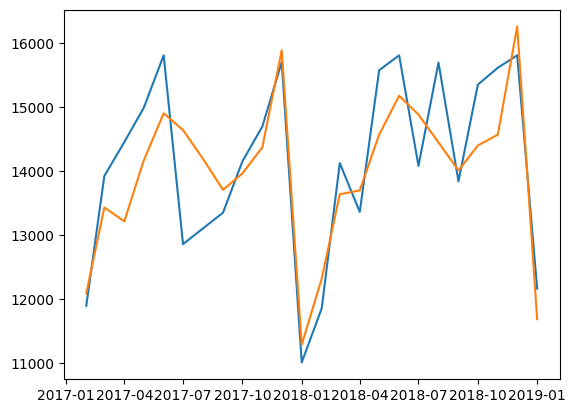

In [ ]:
plt.plot(test_x,label='test_actual')
plt.plot(forecast_1, label='test_pred')

In [ ]:
model = SARIMAX(train_x.Sales, order=(5,1,1), seasonal_order=(3,1,1,12))
model_fit = model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast_res = model_fit.get_forecast(steps=100)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int(alpha=0.05)

In [ ]:
forecast_ci

,lower Sales,upper Sales
2017-02-01,10910.126499,13260.230264
2017-03-01,12250.034848,14609.925049
2017-04-01,12020.700429,14403.364949
2017-05-01,12944.676914,15378.542357
2017-06-01,13680.886635,16125.611990
...,...,...
2025-01-01,12284.867793,15582.492238
2025-02-01,13309.841248,16703.525970
2025-03-01,14699.386734,18095.983662
2025-04-01,14701.194703,18102.470979


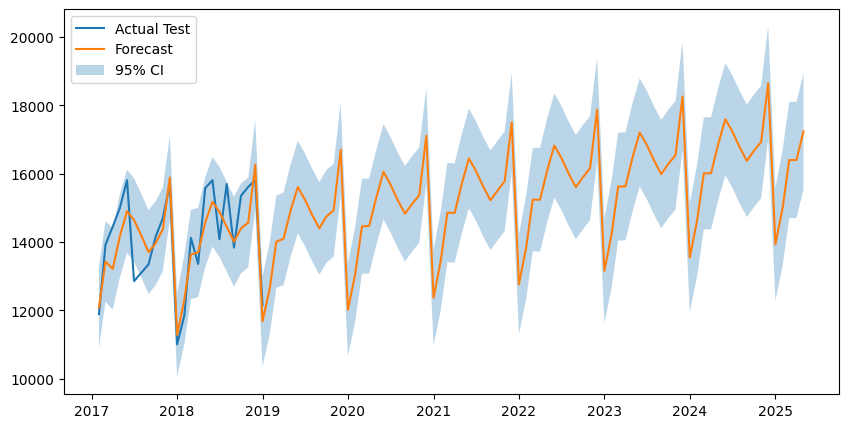

In [ ]:
plt.figure(figsize=(10,5))

# 1. Plot test data ONLY IF it aligns with forecast index
plt.plot(test_x.index, test_x.Sales, label='Actual Test')

# 2. Plot forecast (future)
plt.plot(forecast_mean.index, forecast_mean, label='Forecast')

# 3. Plot forecast confidence intervals (will widen)
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3,
    label='95% CI'
)

plt.legend()
plt.show()


# Change point

In [ ]:
mobile_sales

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00
...,...
2018-09-01,13838.00
2018-10-01,15351.00
2018-11-01,15615.00


In [ ]:
pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.2 MB/s eta 0:00:00


In [ ]:
import ruptures as rpt
import matplotlib.pyplot as plt

# l2 - linear , rbf - non linear
model = rpt.Pelt(model="rbf").fit(mobile_sales)

change_points = model.predict(pen=1)

print("Detected change points (indices):", change_points)

Detected change points (indices): [30, 65, 110, 135, 185, 217]


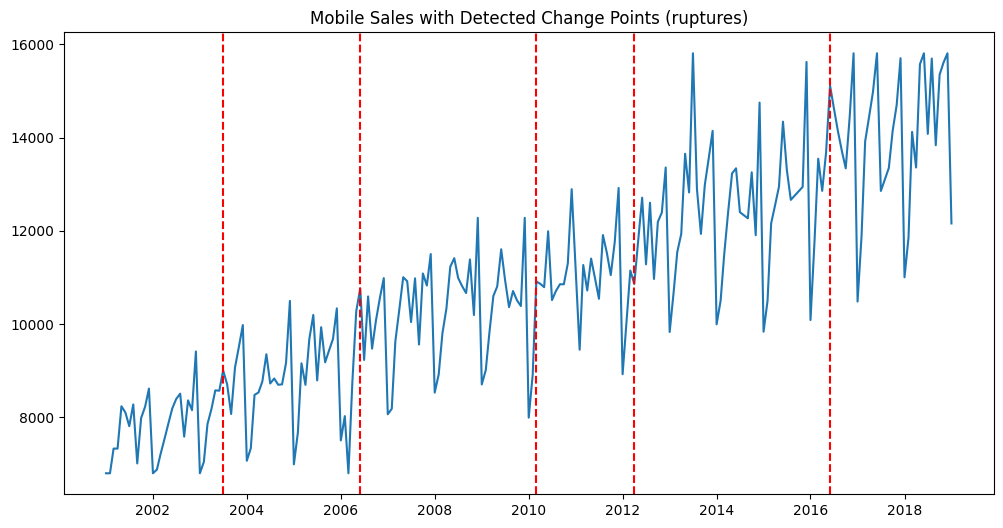

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(mobile_sales.index,mobile_sales, label="Mobile Sales")

# Draw vertical lines for detected change points
for cp in change_points[:-1]:  # last point is length of series
    plt.axvline(x=mobile_sales.index[cp], color='red', linestyle='--', label='Change Point')


plt.title("Mobile Sales with Detected Change Points (ruptures)")
plt.show()


In [ ]:
!gdown 16TAoRZ3S8ebgIq3dPQmWIXPw_1dZy3ta

Downloading...
From: https://drive.google.com/uc?id=16TAoRZ3S8ebgIq3dPQmWIXPw_1dZy3ta
To: /content/rest_vis.csv
100% 13.1k/13.1k [00:00<00:00, 32.2MB/s]


In [ ]:
df = pd.read_csv('/content/rest_vis.csv')
df.head()

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0


In [ ]:
df.head(15)

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0
5,1/6/2016,Wednesday,0,83.0
6,1/7/2016,Thursday,0,69.0
7,1/8/2016,Friday,0,149.0
8,1/9/2016,Saturday,0,234.0
9,1/10/2016,Sunday,0,212.0


In [ ]:
df

,date,weekday,holiday,total
0,1/1/2016,Friday,1,296.0
1,1/2/2016,Saturday,0,191.0
2,1/3/2016,Sunday,0,202.0
3,1/4/2016,Monday,0,105.0
4,1/5/2016,Tuesday,0,98.0
...,...,...,...,...
512,5/27/2017,Saturday,0,NaN
513,5/28/2017,Sunday,0,NaN
514,5/29/2017,Monday,1,NaN
515,5/30/2017,Tuesday,0,NaN


In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Set date as index
df = df.set_index('date').sort_index()

In [ ]:
(df.index[-1] - df.index[0]).days + 1

517

In [ ]:
len(df)

517

In [ ]:
df.isna().sum()

,0
weekday,0
holiday,0
total,39


In [ ]:
df

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0
...,...,...,...
2017-05-27,Saturday,0,NaN
2017-05-28,Sunday,0,NaN
2017-05-29,Monday,1,NaN


In [ ]:
df[df['total'].isna()].index

DatetimeIndex(['2017-04-23', '2017-04-24', '2017-04-25', '2017-04-26',
               '2017-04-27', '2017-04-28', '2017-04-29', '2017-04-30',
               '2017-05-01', '2017-05-02', '2017-05-03', '2017-05-04',
               '2017-05-05', '2017-05-06', '2017-05-07', '2017-05-08',
               '2017-05-09', '2017-05-10', '2017-05-11', '2017-05-12',
               '2017-05-13', '2017-05-14', '2017-05-15', '2017-05-16',
               '2017-05-17', '2017-05-18', '2017-05-19', '2017-05-20',
               '2017-05-21', '2017-05-22', '2017-05-23', '2017-05-24',
               '2017-05-25', '2017-05-26', '2017-05-27', '2017-05-28',
               '2017-05-29', '2017-05-30', '2017-05-31'],
              dtype='datetime64[ns]', name='date', freq=None)

In [ ]:
df.tail(39).isna().sum()

,0
weekday,0
holiday,0
total,39


In [ ]:
df.dropna(inplace = True)

In [ ]:
df

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0
...,...,...,...
2017-04-18,Tuesday,0,91.0
2017-04-19,Wednesday,0,79.0
2017-04-20,Thursday,0,90.0


<Axes: xlabel='date'>

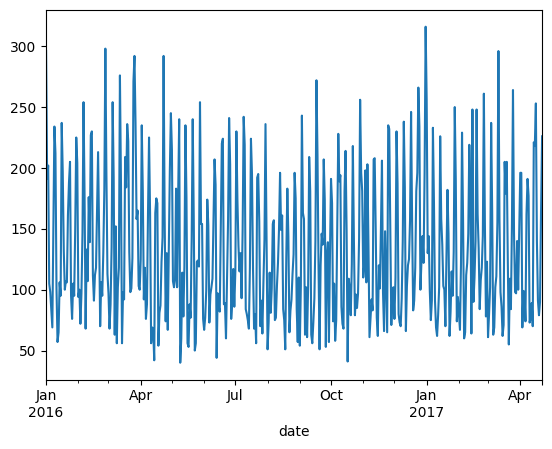

In [ ]:
df['total'].plot()

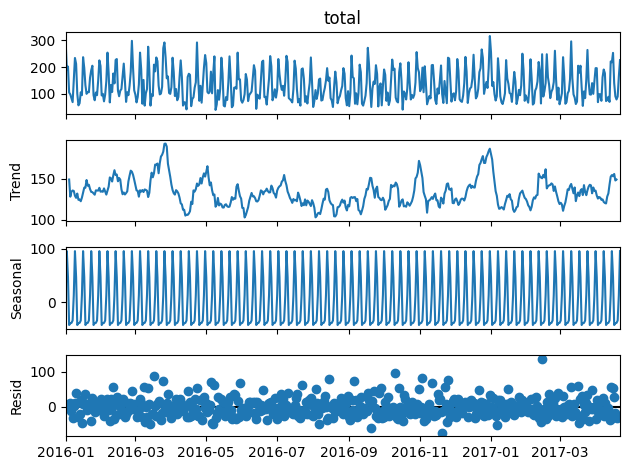

In [ ]:
import statsmodels.api as sm
sm.tsa.seasonal_decompose(df.total,model='additive').plot();

In [ ]:
train_x = df[['total']].iloc[:464]
test_x = df[['total']].iloc[464:]

In [ ]:
test_x

,total
date,
2017-04-09,177.0
2017-04-10,73.0
2017-04-11,77.0
2017-04-12,89.0
2017-04-13,70.0
2017-04-14,221.0
2017-04-15,218.0
2017-04-16,253.0
2017-04-17,140.0


In [ ]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

adf_test(train_x.total)

Sequence is stationary


<Axes: xlabel='date'>

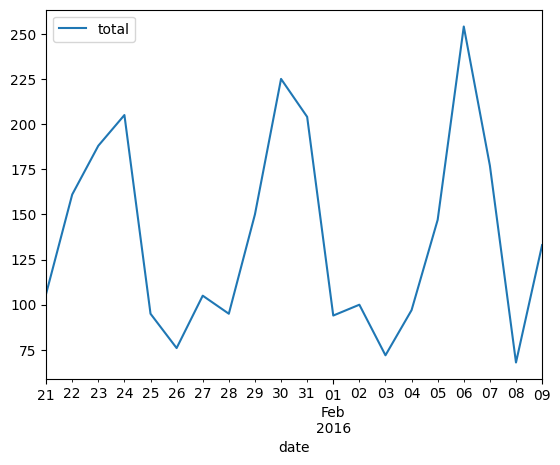

In [ ]:
train_x[20:40].plot()

<Axes: xlabel='date'>

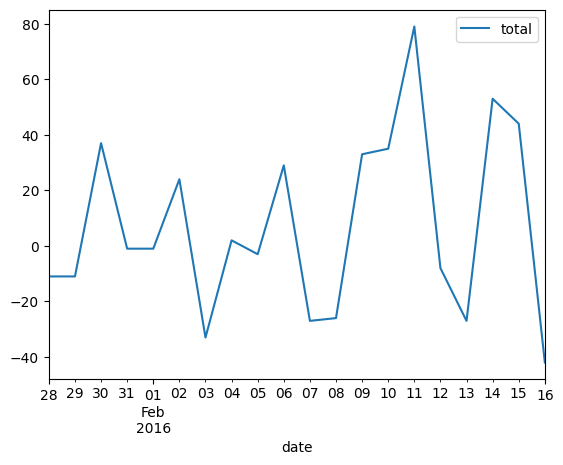

In [ ]:
train_x.diff(7).dropna()[20:40].plot()

<Figure size 800x400 with 0 Axes>

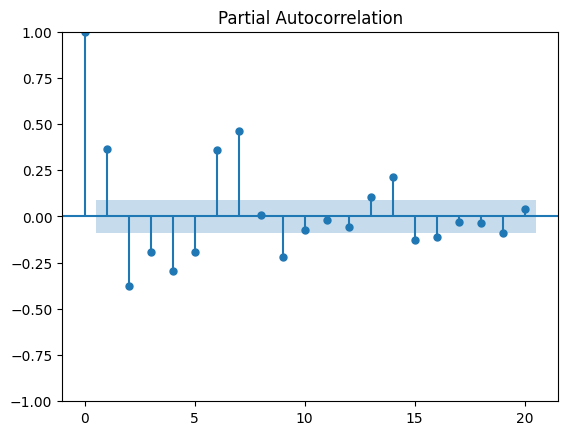

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf


# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_pacf(train_x['total'], lags=20)
plt.show()

<Figure size 800x400 with 0 Axes>

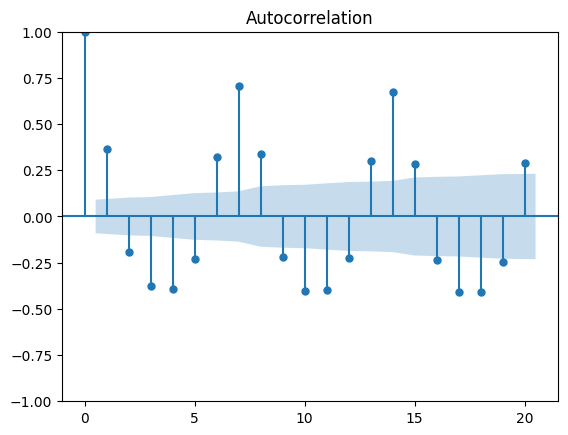

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf


# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_acf(train_x['total'], lags=20)
plt.show()

<Figure size 800x400 with 0 Axes>

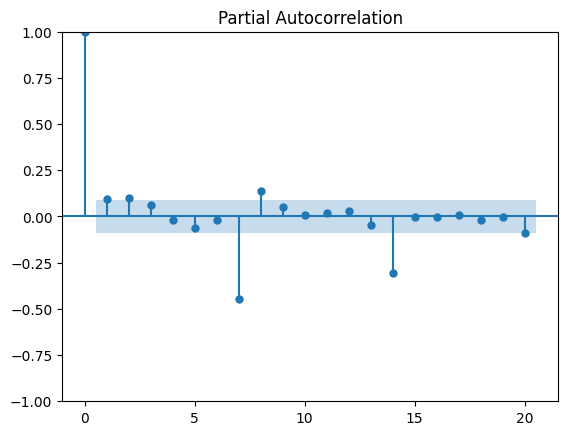

In [ ]:
# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_pacf(train_x['total'].diff(7).dropna(), lags=20)
plt.show()

<Figure size 800x400 with 0 Axes>

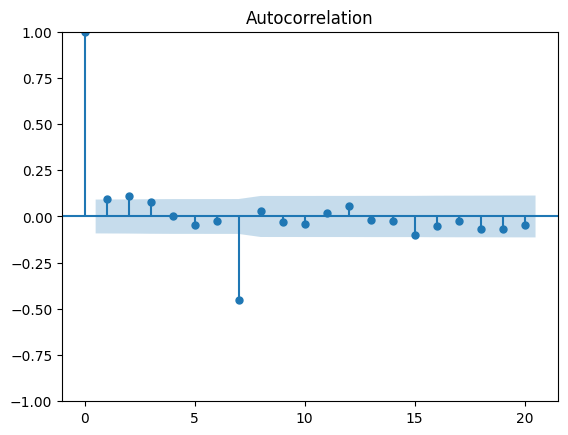

In [ ]:
# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_acf(train_x['total'].diff(7).dropna(), lags=20)
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train_x.total, order=(6, 0, 6),seasonal_order=(3,1,2,7))
model = model.fit(disp=False)

# Step 3: Optional - one-step forecast
forecast_1 = model.forecast(steps=14)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(array([17265., 17267., 17269., 17271., 17273., 17275., 17277.]),
 [Text(17265.0, 0, '2017-04-09'),
  Text(17267.0, 0, '2017-04-11'),
  Text(17269.0, 0, '2017-04-13'),
  Text(17271.0, 0, '2017-04-15'),
  Text(17273.0, 0, '2017-04-17'),
  Text(17275.0, 0, '2017-04-19'),
  Text(17277.0, 0, '2017-04-21')])

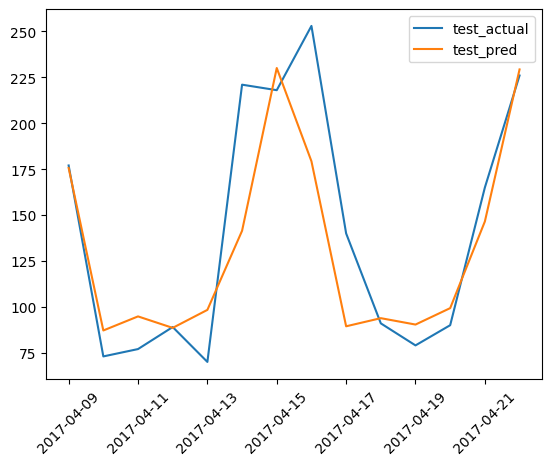

In [ ]:
plt.plot(test_x,label='test_actual')
plt.plot(forecast_1, label='test_pred')
plt.legend()
plt.xticks(rotation=45)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape

mape(test_x, forecast_1)

0.16537491554083508

In [ ]:
test_x['forecast'] = forecast_1

In [ ]:
test_x

,total,forecast
date,,
2017-04-09,177.0,167.101398
2017-04-10,73.0,88.257712
2017-04-11,77.0,94.233951
2017-04-12,89.0,91.740134
2017-04-13,70.0,93.533393
2017-04-14,221.0,141.872864
2017-04-15,218.0,228.708135
2017-04-16,253.0,175.284545
2017-04-17,140.0,87.512776


In [ ]:
df

,weekday,holiday,total
date,,,
2016-01-01,Friday,1,296.0
2016-01-02,Saturday,0,191.0
2016-01-03,Sunday,0,202.0
2016-01-04,Monday,0,105.0
2016-01-05,Tuesday,0,98.0
...,...,...,...
2017-04-18,Tuesday,0,91.0
2017-04-19,Wednesday,0,79.0
2017-04-20,Thursday,0,90.0
